# Anomaly Detection in Transactions — 03 Model Building

Three **unsupervised** anomaly detectors are fit on the scaled features with **no access to the labels**:

- **Isolation Forest** — isolates points via random splits; anomalies need fewer splits.
- **Local Outlier Factor** — flags points in low-density neighbourhoods.
- **One-Class SVM** — learns a boundary around the dense 'normal' region.

Contamination is set to the fraud rate. The true `Class` is used **only after** scoring, to evaluate ranking quality with ROC-AUC, PR-AUC (Average Precision — the right metric under heavy imbalance), and precision@k (k = number of true frauds). All numbers are run, not assumed.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils

cleaned = pd.read_csv('data/creditcard_cleaned.csv')
y = cleaned['Class'].values
X = cleaned.drop(columns='Class').values
contamination = float(y.mean())
print('rows:', len(y), '| frauds:', int(y.sum()), '| contamination:', round(contamination, 4))

rows: 20492 | frauds: 492 | contamination: 0.024


## 1. Fit all three detectors & compare

`run_all_models` fits each detector unsupervised and evaluates its anomaly scores against the held-out labels.

In [2]:
results, scores = utils.run_all_models(X, y, contamination)
results.sort_values('pr_auc', ascending=False).reset_index(drop=True)

,model,roc_auc,pr_auc,precision@k,recall@k,flag_precision,flag_recall,flag_f1,n_flagged
0,Isolation Forest,0.9447,0.6438,0.5894,0.5894,0.5894,0.5894,0.5894,492
1,One-Class SVM,0.9179,0.2445,0.3272,0.3272,0.2891,0.5183,0.3712,882
2,Local Outlier Factor,0.5019,0.0384,0.0610,0.0610,0.0610,0.0610,0.0610,492


## 2. Precision-Recall curves

Under 2.4% prevalence, PR curves (and Average Precision) are far more informative than ROC. The dashed line is the random baseline (= fraud rate).

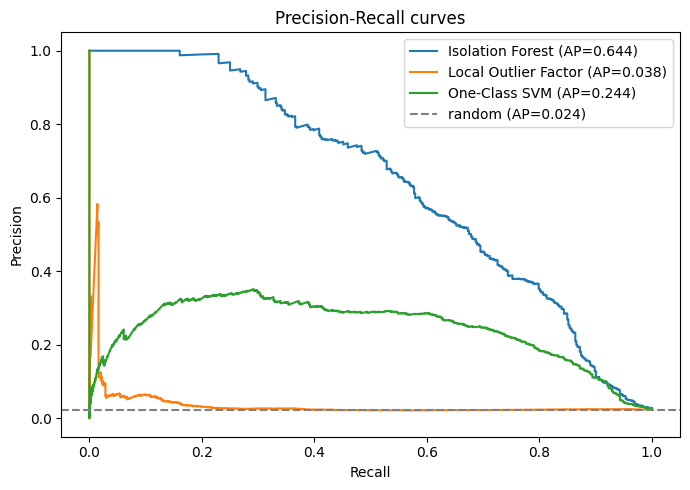

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
utils.plot_pr_curves(scores, y, ax=ax); plt.tight_layout(); plt.show()

## 3. Best model — anomaly-score separation

For the strongest detector, the distribution of anomaly scores for genuine vs fraud shows how cleanly fraud is pushed to the high-score tail.

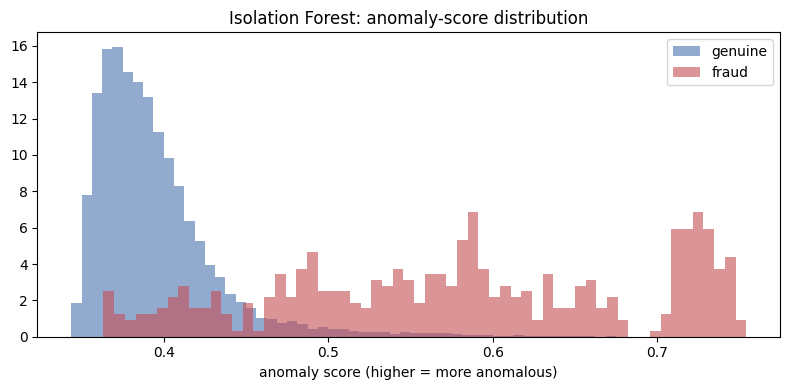

In [4]:
best = results.sort_values('pr_auc', ascending=False).iloc[0]['model']
s = scores[best]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s[y==0], bins=60, alpha=0.6, label='genuine', color='#4c72b0', density=True)
ax.hist(s[y==1], bins=60, alpha=0.6, label='fraud', color='#c44e52', density=True)
ax.set_title(f'{best}: anomaly-score distribution'); ax.set_xlabel('anomaly score (higher = more anomalous)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Top-k precision sweep (best model)

If an analyst can only review the top-N most anomalous transactions, how many are actually fraud? This is the operational metric for a triage queue.

In [5]:
order = np.argsort(s)[::-1]
for n in [50, 100, 200, 492, 1000]:
    topn = order[:n]
    hits = int(y[topn].sum())
    print(f'top {n:4d} flagged -> {hits:3d} fraud  | precision {hits/n:.3f}  | recall {hits/int(y.sum()):.3f}')

top   50 flagged ->  50 fraud  | precision 1.000  | recall 0.102
top  100 flagged ->  99 fraud  | precision 0.990  | recall 0.201
top  200 flagged -> 168 fraud  | precision 0.840  | recall 0.341
top  492 flagged -> 290 fraud  | precision 0.589  | recall 0.589
top 1000 flagged -> 379 fraud  | precision 0.379  | recall 0.770


## 5. Summary & takeaways

- **Isolation Forest is the clear winner**: ROC-AUC **0.945**, PR-AUC **0.644**, and **59% precision@k** — of the top 492 most-anomalous transactions, ~290 are real fraud, from a model that never saw a label.
- **One-Class SVM** ranks fraud well (ROC-AUC 0.918) but with much lower precision (PR-AUC 0.245) — more false positives among its top scores.
- **Local Outlier Factor essentially fails** (ROC-AUC 0.502 ≈ random): local-density outlier detection breaks down in this 30-dimensional PCA space.
- **PR-AUC, not ROC-AUC, tells the real story** under 2.4% prevalence — all three look respectable on ROC, but PR-AUC exposes the gap between Isolation Forest and the rest.
- Unsupervised detection is a strong **triage** tool here, not a replacement for a supervised classifier: it surfaces most fraud into a reviewable shortlist with zero labels.